## Basics

In [71]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

0.23.9


In [72]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251023"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [73]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [74]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc


def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
    return newdf_a
        
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

## Formulas to run


In [75]:
fallingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx")
MBONList = list(fallingexcel['MBON'].unique())

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Code

In [38]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


In [ ]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
    df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]
    
    ntloblist = []
    mbonloclst = []
    df_nttotal = df_nt2.copy()
    for n in df_nt2['MBON']:    
        ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df_nttotal['NT'] = ntloblist
    df_nttotal['Name'] = mbonloclst
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'red'
        nttypes_color = ['mediumorchid', "darkorange", "slategrey"]
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'green'
        nttypes_color = ['blue', "darkturquoise", "indigo"]
    
    
    figntplot, axes = plt.subplots(3,4, figsize=(20,15))
    axscatter_nt = axes.flatten()
    nttypes = ['Glutamate', "Acetylcholine", "GABA"]
    
    metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
    plotcounter = 0
    
    for n,j in zip(nttypes, nttypes_color):
        unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
        
        for k in metrictype:
            x_label_1 = k
            y_label_1 = 'PI_Δg_OSAR'      

            data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1].abs() < 0.2) & (unfiltered_dfnt[y_label_1].abs() < 0.2))].reset_index(drop=True)
            #data_nt = unfiltered_dfnt.copy()
          
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter])
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])
            sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color=j, edgecolors="face", ax=axscatter_nt[plotcounter])
    
            axscatter_nt[plotcounter].grid(False)
            axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
            axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
            axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls='--')
            axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls='--')
           
            axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)
    
            for m, p in enumerate(data_nt['MBON']):
                axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize=10)
    
            # Correlation for subplot
            pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
            civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
            civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
            axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
                                    (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
            
            # Naming of nt type
            axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color=j, weight="bold", fontsize=8)
            plotcounter += 1
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
    
    figntplot.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".png", dpi=1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

## clustering code

In [60]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder', 'Speed ratio_Hg_OSAR',
       'Bout Speed ratio_Hg_OSAR'])
df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]

ntloblist = []
mbonloclst = []
df_nttotal = df_nt2.copy()
for n in df_nt2['MBON']:    
    ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_nttotal['NT'] = ntloblist
df_nttotal['Name'] = mbonloclst

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"]
    colorline = 'red'
    nttypes_color = ['mediumorchid', "darkorange", "slategrey"]

if responder == 'ACR':
    responderrename = "GtACR1"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"]
    colorline = 'green'
    nttypes_color = ['blue', "darkturquoise", "indigo"]
    
#g = sns.PairGrid(plot_data, vars=key_metrics, hue = 'NT')

In [64]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


In [68]:
df_nta = df_neurotrans.drop(columns = ['responder', 'Name'])
df_ntb = df_nta.set_index('MBON')
df_ntc = df_nta[df_nta['MBON'].isin(singlecellmbon)].set_index('MBON')

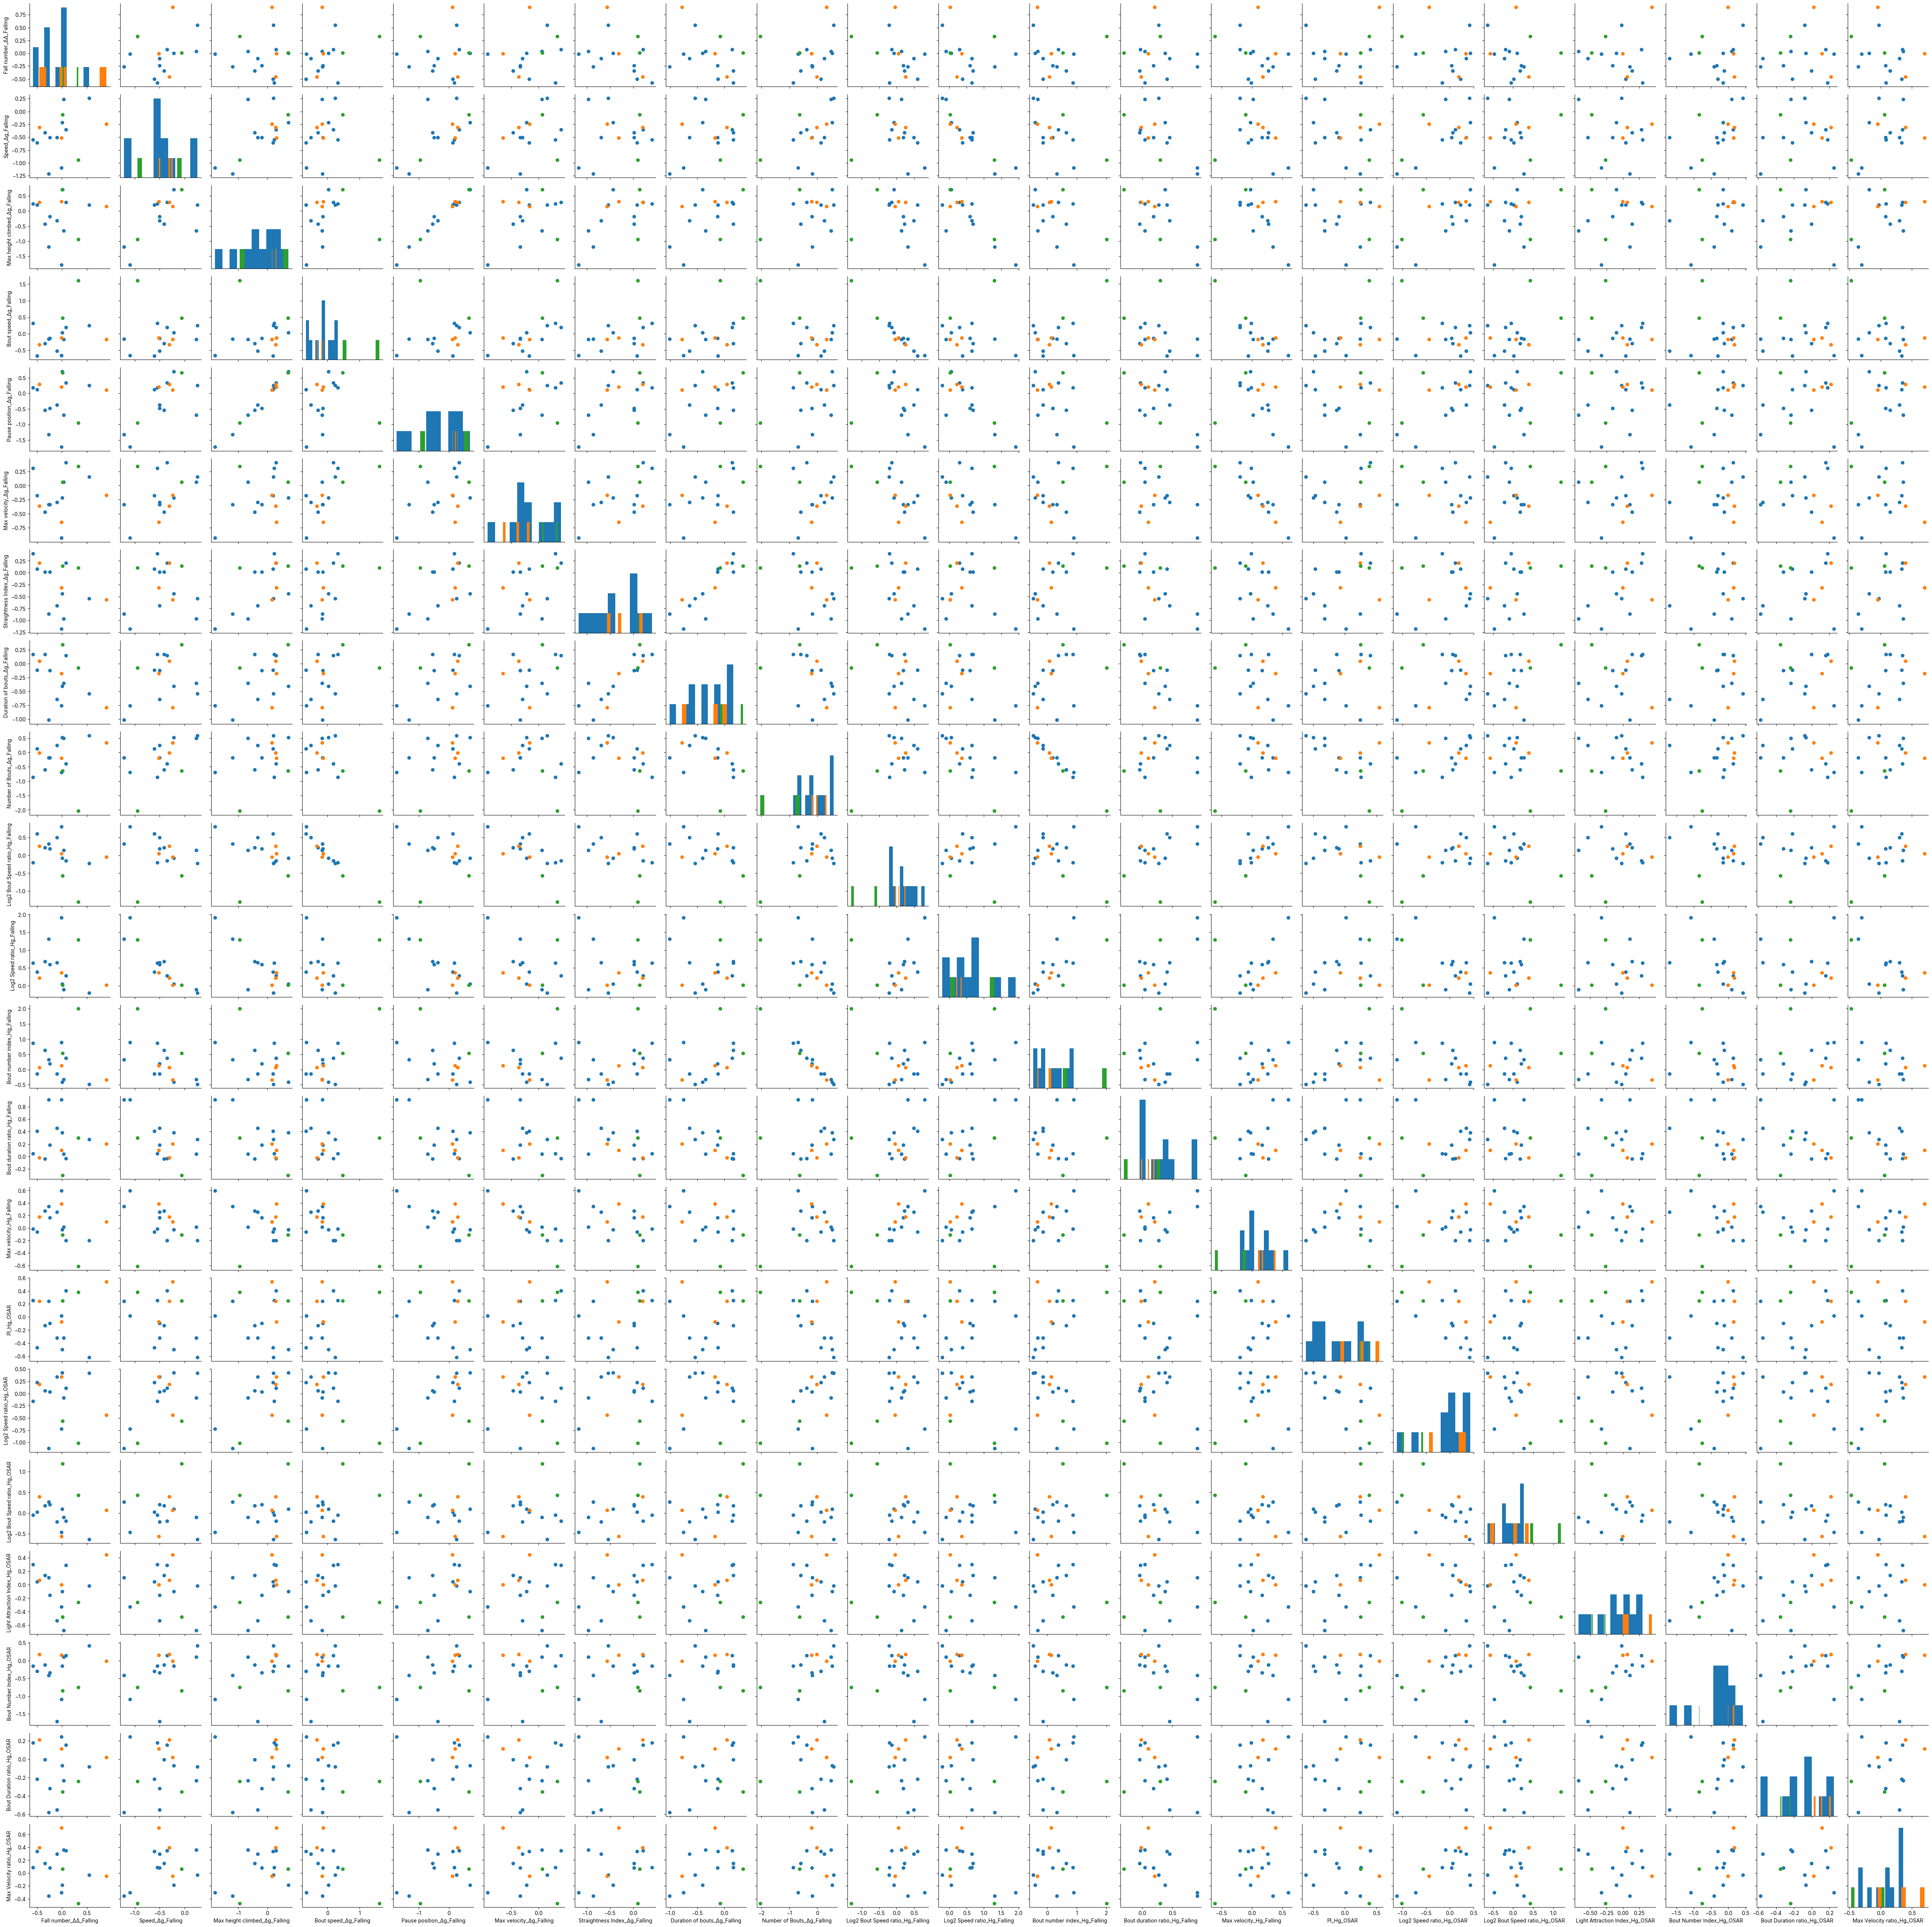

In [69]:
g = sns.PairGrid(df_ntc, hue = 'NT')
g.map_diag(plt.hist)
g.map_upper(plt.scatter)
g.map_lower(plt.scatter)

## NT code

In [79]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Prepare data for clustering
df_clustermbons = df_ntb.copy()
df_cluster = df_clustermbons.drop(columns=['NT']).fillna(0)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_cluster)

# Apply 4 clustering methods
n_clusters = 3

# K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(data_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)
dbscan_labels = dbscan.fit_predict(data_scaled)

# Gaussian Mixture
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(data_scaled)

# Calculate silhouette scores
sil_kmeans = silhouette_score(data_scaled, kmeans_labels)
sil_hierarchical = silhouette_score(data_scaled, hierarchical_labels)
sil_dbscan = silhouette_score(data_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1
sil_gmm = silhouette_score(data_scaled, gmm_labels)

# Create results dataframe
results = pd.DataFrame({
    'Method': ['K-means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Silhouette Score': [sil_kmeans, sil_hierarchical, sil_dbscan, sil_gmm],
    'N Clusters': [len(set(kmeans_labels)), len(set(hierarchical_labels)), 
                   len(set(dbscan_labels)), len(set(gmm_labels))]
})

print("Clustering Comparison Results:")
print(results.sort_values('Silhouette Score', ascending=False))

best_method = results.loc[results['Silhouette Score'].idxmax(), 'Method']
print(f"\nBest method: {best_method}")

# Add cluster labels to dataframe
df_clustermbons_clustered = df_clustermbons.copy()
df_clustermbons_clustered['KMeans'] = kmeans_labels
df_clustermbons_clustered['Hierarchical'] = hierarchical_labels
df_clustermbons_clustered['DBSCAN'] = dbscan_labels
df_clustermbons_clustered['GMM'] = gmm_labels

# Compare with neurotransmitter types
print("\nClustering vs Neurotransmitter Alignment:")
for method, labels in [('KMeans', kmeans_labels), ('Hierarchical', hierarchical_labels), 
                       ('DBSCAN', dbscan_labels), ('GMM', gmm_labels)]:
    ari = adjusted_rand_score(df_clustermbons['NT'].factorize()[0], labels)
    print(f"{method}: ARI = {ari:.3f}")

# PCA for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
df_clustermbons_clustered['PCA1'] = pca_data[:, 0]
df_clustermbons_clustered['PCA2'] = pca_data[:, 1]

Clustering Comparison Results:
         Method  Silhouette Score  N Clusters
1  Hierarchical          0.304782           3
0       K-means          0.204302           3
3           GMM          0.204302           3
2        DBSCAN         -1.000000           1

Best method: Hierarchical

Clustering vs Neurotransmitter Alignment:
KMeans: ARI = -0.088
Hierarchical: ARI = -0.024
DBSCAN: ARI = 0.000
GMM: ARI = -0.088


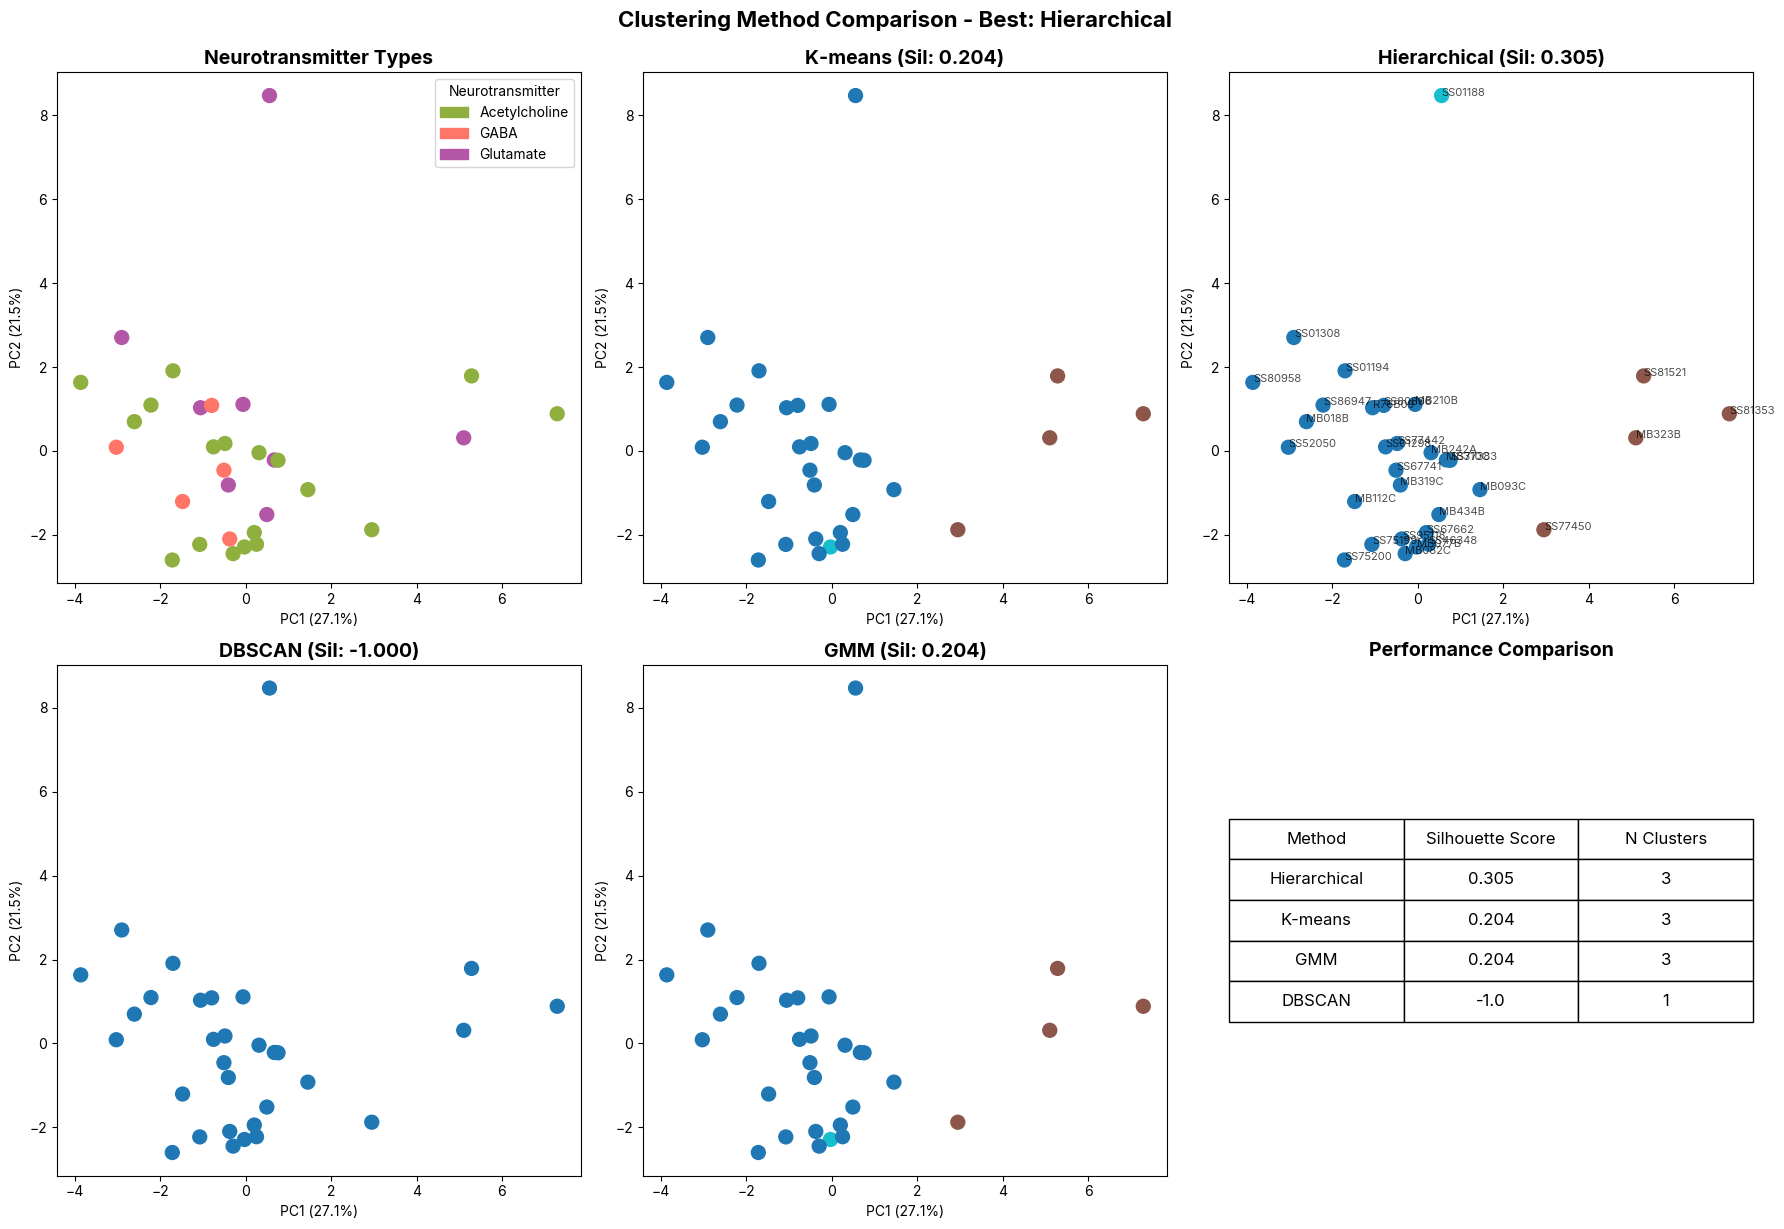


Hierarchical Clusters vs Neurotransmitter Types:
Hierarchical    0  1  2  All
NT                          
Acetylcholine  15  3  0   18
GABA            5  0  0    5
Glutamate       6  1  1    8
All            26  4  1   31


In [108]:
import matplotlib.patches as mpatches
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

#colors for plot 1
nt_color_map = {
    'Acetylcholine': "#8FAF3F",  # Red
    'GABA': "#FF7668",           # Purple
    'Glutamate': "#B256A5"       # Brown
}

nt_cat = df_clustermbons_clustered['NT'].astype('category')
point_colors = [nt_color_map[nt] for nt in df_clustermbons_clustered['NT']]

# Neurotransmitter types (reference)
axes[0,0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=point_colors, s=100)
axes[0,0].set_title('Neurotransmitter Types', fontsize=14, weight='bold')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

handles = [mpatches.Patch(color=nt_color_map[nt], label=nt) 
           for nt in nt_cat.cat.categories]
axes[0,0].legend(handles=handles, title='Neurotransmitter')

# K-means
axes[0,1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['KMeans'], cmap='tab10', s=100)
axes[0,1].set_title(f'K-means (Sil: {sil_kmeans:.3f})', fontsize=14, weight='bold')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Hierarchical
axes[0,2].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['Hierarchical'], cmap='tab10', s=100)
axes[0,2].set_title(f'Hierarchical (Sil: {sil_hierarchical:.3f})', fontsize=14, weight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# DBSCAN
axes[1,0].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['DBSCAN'], cmap='tab10', s=100)
axes[1,0].set_title(f'DBSCAN (Sil: {sil_dbscan:.3f})', fontsize=14, weight='bold')
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# GMM
axes[1,1].scatter(df_clustermbons_clustered['PCA1'], df_clustermbons_clustered['PCA2'], 
                  c=df_clustermbons_clustered['GMM'], cmap='tab10', s=100)
axes[1,1].set_title(f'GMM (Sil: {sil_gmm:.3f})', fontsize=14, weight='bold')
axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Results table
axes[1,2].axis('off')
table_data = results.sort_values('Silhouette Score', ascending=False).round(3)
table = axes[1,2].table(cellText=table_data.values, colLabels=table_data.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
axes[1,2].set_title('Performance Comparison', fontsize=14, weight='bold')

# Add MBON labels to best performing plot
best_ax = None
if best_method == 'K-means':
    best_ax = axes[0,1]
elif best_method == 'Hierarchical':
    best_ax = axes[0,2]
elif best_method == 'DBSCAN':
    best_ax = axes[1,0]
elif best_method == 'GMM':
    best_ax = axes[1,1]

if best_ax is not None:
    for i, mbon in enumerate(df_clustermbons_clustered.index):
        best_ax.annotate(mbon, (df_clustermbons_clustered['PCA1'].iloc[i], df_clustermbons_clustered['PCA2'].iloc[i]), 
                        fontsize=8, alpha=0.7)

plt.tight_layout()
plt.suptitle(f'Clustering Method Comparison - Best: {best_method}', fontsize=16, weight='bold', y=1.02)
#plt.savefig(filesavedir + date + '_clustering_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# Cross-tabulation of best method with neurotransmitter types
best_labels = df_clustermbons_clustered[best_method] if best_method in df_clustermbons_clustered.columns else kmeans_labels
crosstab = pd.crosstab(df_clustermbons_clustered['NT'], best_labels, margins=True)
print(f"\n{best_method} Clusters vs Neurotransmitter Types:")
print(crosstab)

In [82]:
df_clustermbons_clustered['NT']

MBON
MB018B     Acetylcholine
MB077B     Acetylcholine
MB082C     Acetylcholine
MB093C     Acetylcholine
MB112C              GABA
MB210B         Glutamate
MB242A     Acetylcholine
MB310C         Glutamate
MB319C         Glutamate
MB323B         Glutamate
MB434B         Glutamate
R76B09         Glutamate
SS01188        Glutamate
SS01194    Acetylcholine
SS01298    Acetylcholine
SS01308        Glutamate
SS46348    Acetylcholine
SS52050             GABA
SS67662    Acetylcholine
SS67741             GABA
SS75199    Acetylcholine
SS75200    Acetylcholine
SS77383    Acetylcholine
SS77442    Acetylcholine
SS77450    Acetylcholine
SS80896             GABA
SS80958    Acetylcholine
SS81353    Acetylcholine
SS81521    Acetylcholine
SS86947    Acetylcholine
SS95118             GABA
Name: NT, dtype: object